In [2]:
#Import the required modules, numpy for calculation, and Matplotlib for drawing
import numpy as np
import matplotlib.pyplot as plt
#This code is for jupyter Notebook only
%matplotlib inline


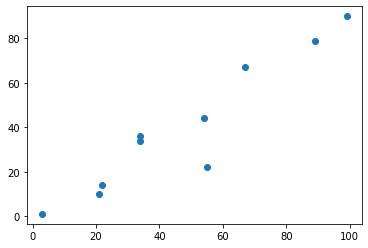

In [3]:
# define data, and change list to array
x = [3,21,22,34,54,34,55,67,89,99]
x = np.array(x)
y = [1,10,14,34,44,36,22,67,79,90]
y = np.array(y)
#Show the effect of a scatter plot
plt.scatter(x,y)

In [4]:
#The basic linear regression model is wx+ b, and since this is a two-dimensional space, the model is ax+ b

def model(a, b, x):
  return a*x + b

#The most commonly used loss function of linear regression model is the loss function of mean variance difference
def loss_function(a, b, x, y):
    num = len(x)
    prediction=model(a,b,x)
    return (0.5/num) * (np.square(prediction-y)).sum()

#The optimization function mainly USES partial derivatives to update two parameters a and b
def optimize(a,b,x,y):
    num = len(x)
    prediction = model(a,b,x)
    #Update the values of A and B by finding the partial derivatives of the loss function on a and b
    da = (1.0/num) * ((prediction -y)*x).sum()
    db = (1.0/num) * ((prediction -y).sum())
    a = a - Lr*da
    b = b - Lr*db
    return a, b

#iterated function, return a and b
error=[]
def iterate(a,b,x,y,times):
    for i in range(times):
        a,b = optimize(a,b,x,y)
        error.append(loss_function(a, b, x, y))
    return a,b,error


[0.6182025]
[0.16123727]
[0.85496912] [0.15162935] 46.371397064382634


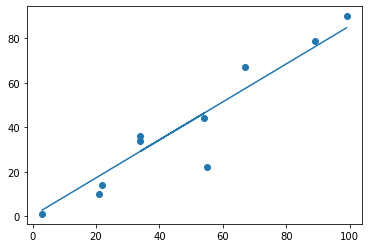

In [5]:
#Initialize parameters and display
a = np.random.rand(1)
print(a)
b = np.random.rand(1)
print(b)
Lr = 1e-4

#For the first iteration, the parameter values, losses, and visualization after the iteration are displayed
a,b,err = iterate(a,b,x,y,100)
prediction=model(a,b,x)
loss = loss_function(a, b, x, y)
print(a,b,loss)
plt.scatter(x,y)
plt.plot(x,prediction)


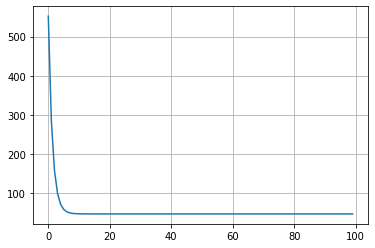

In [35]:
plt.plot(err)
plt.grid()

In [53]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(  )
X_train=x.reshape(-1,1)
Y_train=y.reshape(-1,1)
model.fit(X_train,Y_train)

LinearRegression()

In [54]:
model.coef_

array([[0.9287452]])

In [55]:
model.score(X_train,Y_train)

0.895183163769148

In [49]:
model.predict([[10]])

array([[4.59343127]])

##  Linear Regression using Keras

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD

In [9]:
# define data, and change list to array
x = [3,21,22,34,54,34,55,67,89,99]
x = np.array(x)
y = [1,10,14,34,44,36,22,67,79,90]
y = np.array(y)
x

array([ 3, 21, 22, 34, 54, 34, 55, 67, 89, 99])

In [10]:
X=pd.DataFrame(x)
Y=pd.DataFrame(y)

In [104]:
model = Sequential()
model.add(Dense(1, input_dim=1))
model.add(Activation('linear'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 1)                 2         
                                                                 
 activation_4 (Activation)   (None, 1)                 0         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [105]:
sgd = SGD(0.0001)
model.compile(loss='mse',optimizer=sgd)

In [106]:
h=model.fit(X,Y,epochs=10,verbose=1)

Epoch 1/10
1/1 [==============================] - 0s 268ms/step - loss: 865.6177
Epoch 2/10
1/1 [==============================] - 0s 7ms/step - loss: 199.2791
Epoch 3/10
1/1 [==============================] - 0s 6ms/step - loss: 107.1201
Epoch 4/10
1/1 [==============================] - 0s 6ms/step - loss: 94.3734
Epoch 5/10
1/1 [==============================] - 0s 6ms/step - loss: 92.6100
Epoch 6/10
1/1 [==============================] - 0s 6ms/step - loss: 92.3655
Epoch 7/10
1/1 [==============================] - 0s 6ms/step - loss: 92.3311
Epoch 8/10
1/1 [==============================] - 0s 6ms/step - loss: 92.3258
Epoch 9/10
1/1 [==============================] - 0s 5ms/step - loss: 92.3245
Epoch 10/10
1/1 [==============================] - 0s 5ms/step - loss: 92.3238


In [94]:
model.save("ghazal.h5")

In [108]:
pred = model.predict(X)
print("X=",X)
print("Pred=",pred)

X=     0
0   3
1  21
2  22
3  34
4  54
5  34
6  55
7  67
8  89
9  99
Pred= [[ 2.5622654]
 [17.996485 ]
 [18.853943 ]
 [29.143421 ]
 [46.292557 ]
 [29.143421 ]
 [47.150013 ]
 [57.43949  ]
 [76.30354  ]
 [84.87811  ]]


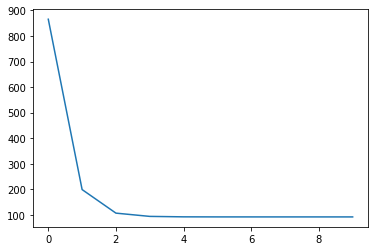

In [107]:
plt.plot(h.history['loss'])